# Chapter 55 — Dot Products as Matching Scores

## Learning goals

Chapter 54 used manually chosen attention weights to compute weighted averages over positions.

The next missing piece is a score that compares one position representation with another.

By the end of this chapter, you should be able to:

- Compute a dot product by hand and with PyTorch.
- Explain the contribution made by each pair of vector components.
- Relate dot products to vector direction and magnitude.
- Draw and compare same, perpendicular, diagonal, and opposite directions in two dimensions.
- Compute one vector's matching scores against many candidates at once.
- Explain why raw dot-product scores are not probabilities or attention weights.
- Normalize vectors and compute cosine similarity.
- Explain when direction-only similarity is useful.
- Explain why controlling dot-product scale matters before softmax.

## The big idea

A dot product multiplies corresponding components and adds the products.

For two-dimensional vectors:

```text
[a, b] · [c, d] = a × c + b × d
```

The result is one scalar that can serve as a raw matching score.

For unit-length vectors, the score is `1` in the same direction, `0` in a perpendicular direction, and `-1` in the opposite direction.

Without controlled lengths, the score measures magnitude as well as direction.

## Terms used in this chapter

- A **dot product** is the sum of pairwise component products from two equal-length vectors.
- A **matching score** is a scalar used to rank how compatible two representations are.
- **Magnitude** or **norm** is a vector's length.
- **Perpendicular vectors** meet at a right angle and have dot product zero when neither is the zero vector.
- **Normalization** rescales a nonzero vector to length one.
- **Cosine similarity** is the dot product divided by both vector lengths.
- A **raw score** has not yet been converted into a normalized distribution.
- **Scaling** changes score magnitude before a later operation such as softmax.

## Create tiny two-dimensional vectors

Start with the required same, perpendicular, and opposite directions.

Two components let us connect arithmetic with a coordinate-plane picture.

In [1]:
import torch

device = "cpu"
reference_vector = torch.tensor(
    [1.0, 0.0],
    dtype=torch.float32,
    device=device,
)
same_vector = torch.tensor(
    [1.0, 0.0],
    dtype=torch.float32,
    device=device,
)
perpendicular_vector = torch.tensor(
    [0.0, 1.0],
    dtype=torch.float32,
    device=device,
)
opposite_vector = torch.tensor(
    [-1.0, 0.0],
    dtype=torch.float32,
    device=device,
)

print("device:", device)
print("reference vector:", reference_vector)
print("same vector:", same_vector)
print("perpendicular vector:", perpendicular_vector)
print("opposite vector:", opposite_vector)

device: cpu
reference vector: tensor([1., 0.])
same vector: tensor([1., 0.])
perpendicular vector: tensor([0., 1.])
opposite vector: tensor([-1.,  0.])


All four tensors have shape `[2]`, so their components can be multiplied pair by pair.

## Compute a dot product manually

Write the definition with straightforward control flow and reject incompatible inputs.

This teaching helper converts tensor entries to Python numbers, so model code should use PyTorch operations when autograd is required.

In [2]:
def manual_dot_product(
    left_vector: torch.Tensor,
    right_vector: torch.Tensor,
) -> float:
    if left_vector.ndim != 1 or right_vector.ndim != 1:
        raise ValueError("Both vectors must be one-dimensional.")
    if left_vector.shape != right_vector.shape:
        raise ValueError("Both vectors must have the same shape.")
    if left_vector.device != right_vector.device:
        raise ValueError("Both vectors must use the same device.")

    total = 0.0
    for index in range(left_vector.shape[0]):
        total += left_vector[index].item() * right_vector[index].item()

    return total


def print_dot_product_steps(
    left_vector: torch.Tensor,
    right_vector: torch.Tensor,
) -> None:
    print("index | left | right | product")
    print("-" * 34)
    for index in range(left_vector.shape[0]):
        left_value = left_vector[index].item()
        right_value = right_vector[index].item()
        print(
            f"{index:>5} | "
            f"{left_value:>4.1f} | "
            f"{right_value:>5.1f} | "
            f"{left_value * right_value:>7.1f}"
        )
    print("-" * 34)
    print("dot product:", manual_dot_product(left_vector, right_vector))


print("reference · same")
print_dot_product_steps(reference_vector, same_vector)
print()
print("reference · perpendicular")
print_dot_product_steps(reference_vector, perpendicular_vector)

reference · same
index | left | right | product
----------------------------------
    0 |  1.0 |   1.0 |     1.0
    1 |  0.0 |   0.0 |     0.0
----------------------------------
dot product: 1.0

reference · perpendicular
index | left | right | product
----------------------------------
    0 |  1.0 |   0.0 |     0.0
    1 |  0.0 |   1.0 |     0.0
----------------------------------
dot product: 0.0


The matching pair produces `1 × 1 + 0 × 0 = 1`.

The perpendicular pair produces `1 × 0 + 0 × 1 = 0`.

## Verify the results with PyTorch

`torch.dot` performs the differentiable one-dimensional operation used by model code.

In [3]:
named_vectors = {
    "same": same_vector,
    "perpendicular": perpendicular_vector,
    "opposite": opposite_vector,
}

print("candidate     | manual score | torch.dot score | match")
print("-" * 61)
for name, candidate_vector in named_vectors.items():
    manual_score = manual_dot_product(reference_vector, candidate_vector)
    torch_score = torch.dot(reference_vector, candidate_vector).item()
    print(
        f"{name:>13} | "
        f"{manual_score:>12.1f} | "
        f"{torch_score:>15.1f} | "
        f"{manual_score == torch_score}"
    )

candidate     | manual score | torch.dot score | match
-------------------------------------------------------------
         same |          1.0 |             1.0 | True
perpendicular |          0.0 |             0.0 | True
     opposite |         -1.0 |            -1.0 | True


The scores `1`, `0`, and `-1` distinguish same, perpendicular, and opposite unit directions.

## Draw the directions

Plot the reference, a diagonal, the perpendicular vector, and the opposite vector on equal axes.

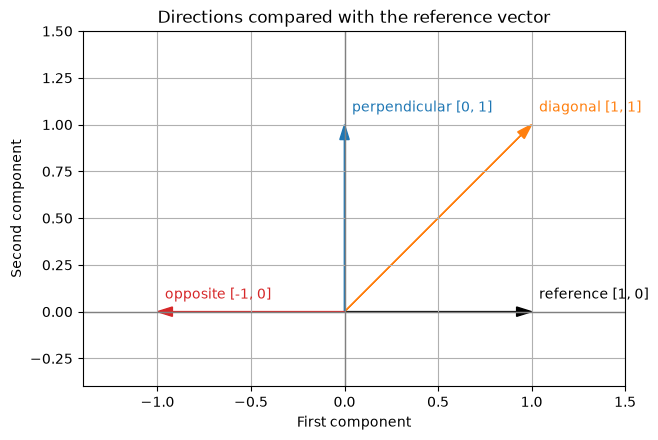

In [4]:
import matplotlib.pyplot as plt

diagonal_vector = torch.tensor(
    [1.0, 1.0],
    dtype=torch.float32,
    device=device,
)
vectors_to_draw = {
    "reference [1, 0]": reference_vector,
    "diagonal [1, 1]": diagonal_vector,
    "perpendicular [0, 1]": perpendicular_vector,
    "opposite [-1, 0]": opposite_vector,
}
colors = ["black", "tab:orange", "tab:blue", "tab:red"]

plt.figure(figsize=(7, 6))
for (label, vector), color in zip(
    vectors_to_draw.items(),
    colors,
    strict=True,
):
    x_component = vector[0].item()
    y_component = vector[1].item()
    plt.arrow(
        0,
        0,
        x_component,
        y_component,
        color=color,
        length_includes_head=True,
        head_width=0.05,
        head_length=0.08,
    )
    plt.text(x_component + 0.04, y_component + 0.07, label, color=color)

plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.xlim(-1.4, 1.5)
plt.ylim(-0.4, 1.5)
plt.xlabel("First component")
plt.ylabel("Second component")
plt.title("Directions compared with the reference vector")
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

The picture gives a geometric interpretation of the arithmetic.

For nonzero vectors `a` and `b`:

```text
a · b = ||a|| × ||b|| × cos(angle between them)
```

The angle term is positive for acute angles, zero at 90 degrees, and negative for opposite-facing directions.

The two norm terms show why direction is not the whole score.

## Compare one vector with many candidates

Stack candidate rows and use matrix-vector multiplication to compute every dot product at once.

Include a diagonal vector and a long same-direction vector to expose the magnitude effect.

In [5]:
candidate_names = [
    "same",
    "diagonal",
    "perpendicular",
    "opposite",
    "long same",
]
candidate_matrix = torch.stack(
    [
        same_vector,
        diagonal_vector,
        perpendicular_vector,
        opposite_vector,
        torch.tensor([10.0, 0.0], device=device),
    ]
)
matching_scores = candidate_matrix @ reference_vector

print("candidate     | vector       | matching score")
print("-" * 52)
for name, vector, score in zip(
    candidate_names,
    candidate_matrix,
    matching_scores,
    strict=True,
):
    rounded_vector = [round(value, 1) for value in vector.tolist()]
    print(f"{name:>13} | {str(rounded_vector):>12} | {score.item():>14.1f}")

print()
print("candidate matrix shape:", candidate_matrix.shape)
print("reference shape:", reference_vector.shape)
print("score shape:", matching_scores.shape)

candidate     | vector       | matching score
----------------------------------------------------
         same |   [1.0, 0.0] |            1.0
     diagonal |   [1.0, 1.0] |            1.0
perpendicular |   [0.0, 1.0] |            0.0
     opposite |  [-1.0, 0.0] |           -1.0
    long same |  [10.0, 0.0] |           10.0

candidate matrix shape: torch.Size([5, 2])
reference shape: torch.Size([2])
score shape: torch.Size([5])


The `[5, 2] @ [2]` operation returns five scores.

The diagonal and same-direction candidates both score `1` even though their angles differ.

The long same-direction vector scores `10`, showing that magnitude can dominate a raw dot product.

## Raw matching scores are not attention weights

Dot products can be negative, unbounded, and need not sum to one.

They are scores that may rank candidates, not normalized probabilities.

Attention will later transform a set of allowed scores with softmax to obtain nonnegative weights that sum to one.

The semantic usefulness of a score also depends on learned representations rather than on the dot-product operation alone.

## Separate direction from magnitude

Print vector norms beside raw dot products to make the length effect explicit.

In [6]:
print("candidate     | norm  | raw dot product")
print("-" * 44)
for name, vector in zip(candidate_names, candidate_matrix, strict=True):
    vector_norm = torch.linalg.vector_norm(vector).item()
    raw_score = torch.dot(reference_vector, vector).item()
    print(f"{name:>13} | {vector_norm:>5.3f} | {raw_score:>15.3f}")

candidate     | norm  | raw dot product
--------------------------------------------
         same | 1.000 |           1.000
     diagonal | 1.414 |           1.000
perpendicular | 1.000 |           0.000
     opposite | 1.000 |          -1.000
    long same | 10.000 |          10.000


The long vector's norm is `10`, and that length multiplies its otherwise identical directional match.

Raw dot-product attention can intentionally use learned magnitudes, so length dependence is a property to understand rather than always an error.

## Normalize for direction-only similarity

Cosine similarity divides the dot product by both nonzero vector norms.

Equivalently, normalize both vectors and take their dot product.

In [7]:
def normalize_vector(vector: torch.Tensor) -> torch.Tensor:
    if vector.ndim != 1:
        raise ValueError("vector must be one-dimensional.")

    vector_norm = torch.linalg.vector_norm(vector)
    if vector_norm.item() == 0.0:
        raise ValueError("The zero vector has no direction to normalize.")

    return vector / vector_norm


def cosine_similarity(
    left_vector: torch.Tensor,
    right_vector: torch.Tensor,
) -> float:
    normalized_left = normalize_vector(left_vector)
    normalized_right = normalize_vector(right_vector)
    return torch.dot(normalized_left, normalized_right).item()


print("candidate     | raw dot | cosine similarity")
print("-" * 51)
for name, vector in zip(candidate_names, candidate_matrix, strict=True):
    raw_score = torch.dot(reference_vector, vector).item()
    cosine_score = cosine_similarity(reference_vector, vector)
    print(f"{name:>13} | {raw_score:>7.3f} | {cosine_score:>17.3f}")

candidate     | raw dot | cosine similarity
---------------------------------------------------
         same |   1.000 |             1.000
     diagonal |   1.000 |             0.707
perpendicular |   0.000 |             0.000
     opposite |  -1.000 |            -1.000
    long same |  10.000 |             1.000


The unit and long same-direction vectors both have cosine similarity `1`, while their raw scores are `1` and `10`.

The diagonal candidate has cosine similarity near `0.707`, exposing the angular difference hidden by its raw score of `1`.

Cosine similarity is undefined for the zero vector because that vector has no direction.

## Score scale changes softmax sharpness

Use two score lists with the same ordering but different magnitudes.

This previews why the scale of attention dot products matters before they become weights.

In [8]:
moderate_scores = torch.tensor(
    [1.0, 0.0, -1.0],
    dtype=torch.float32,
    device=device,
)
large_scores = 10 * moderate_scores
moderate_weights = torch.softmax(moderate_scores, dim=0)
large_score_weights = torch.softmax(large_scores, dim=0)

print("scores          | softmax weights                 | largest weight")
print("-" * 76)
print(
    f"{str(moderate_scores.tolist()):>15} | "
    f"{str([round(value, 6) for value in moderate_weights.tolist()]):>31} | "
    f"{moderate_weights.max().item():.6f}"
)
print(
    f"{str(large_scores.tolist()):>15} | "
    f"{str([round(value, 6) for value in large_score_weights.tolist()]):>31} | "
    f"{large_score_weights.max().item():.6f}"
)

scores          | softmax weights                 | largest weight
----------------------------------------------------------------------------
[1.0, 0.0, -1.0] |  [0.665241, 0.244728, 0.090031] | 0.665241
[10.0, 0.0, -10.0] |        [0.999955, 4.5e-05, 0.0] | 0.999955


Multiplying every score by ten preserves the ranking but makes softmax concentrate almost all weight on the largest score.

In scaled dot-product attention, many component products are added, and their typical spread can grow with the query/key dimension under common initialization assumptions.

Dividing by the square root of that dimension helps keep score scale in a useful range.

The exact scaled-attention formula will be introduced after queries and keys are defined.

## Connect scores to the attention pipeline

Chapter 54 began with weights and used them to average vectors.

This chapter supplies the raw comparison step:

```text
position representations
→ dot-product matching scores
→ normalization into attention weights
→ weighted average
```

Queries and keys will specify which representations are compared, while values will specify which vectors are averaged.

## Common mistakes

- Do not compute a dot product between vectors with different lengths.
- Do not describe raw dot products as probabilities or normalized attention weights.
- Do not say that a dot product measures direction only.
- Do not assume a high algebraic score guarantees semantic similarity.
- Do not normalize the zero vector because its direction is undefined.
- Do not assume normalization is always required because learned magnitudes can carry useful information.
- Do not ignore score scale before softmax.

## Takeaways

A dot product multiplies matching components, adds them, and returns one scalar.

For the required unit vectors:

```text
[1, 0] · [1, 0]  =  1
[1, 0] · [0, 1]  =  0
[1, 0] · [-1, 0] = -1
```

Its geometric value is `||a|| × ||b|| × cos(θ)`, so both magnitude and direction affect the result.

Cosine similarity removes magnitude effects by normalizing nonzero vectors.

In attention, dot products provide raw matching scores that must still be scaled, masked when causal, and normalized into weights.

## What comes next

The next chapter turns a set of dot-product scores into an attention distribution with masking and softmax.

That connects vector matching to the weighted averages from Chapter 54 before the full query, key, and value layer is assembled.